In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import mutual_info_regression

In [ ]:
# ----------------------------
# 1) Load merged dataset + dictionaries
# ----------------------------
df = pd.read_csv(
    "/Users/ramilmammadov/Desktop/Capstone Project/NRI_HPI/nri_hpi_data_full.csv",
    low_memory=False,
)

try:
    nri_dict = pd.read_csv(
        "/Users/ramilmammadov/Desktop/Capstone Project/NRI_HPI/NRIDataDictionary.csv",
        low_memory=False,
    )
    if nri_dict.empty:
        nri_dict = None
except Exception:
    nri_dict = None

try:
    hpi_dict = pd.read_excel(
        "/Users/ramilmammadov/Desktop/Capstone Project/NRI_HPI/hpi_dictionary.xlsx"
    )
except Exception:
    hpi_dict = (
        None  # not used directly, but available if you want to annotate target later
    )

In [ ]:
# ----------------------------
# 2) Target column (hpi_change)
# ----------------------------
target_col = next((c for c in df.columns if c.lower() == "hpi_change"), None)
if target_col is None:
    for c in df.columns:
        if re.fullmatch(r"hpi[_\s]?change", c, flags=re.IGNORECASE):
            target_col = c
            break
if target_col is None:
    raise KeyError(
        "Couldn't find a target column named 'hpi_change' (case-insensitive)."
    )

y_all = pd.to_numeric(df[target_col], errors="coerce")

In [ ]:
# ----------------------------
# 3) Predictors = ALL numeric cols except the target
#    (only drop >40% missing and constants for stability)
# ----------------------------
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
predictor_cols = []
for c in numeric_cols:
    if c == target_col:
        continue
    s = pd.to_numeric(df[c], errors="coerce")
    if s.isna().mean() > 0.40:  # drop high-missing
        continue
    if s.nunique(dropna=True) <= 1:  # drop constants
        continue
    predictor_cols.append(c)

if not predictor_cols:
    raise RuntimeError("No usable numeric predictors after filtering.")

In [ ]:
# ----------------------------
# 4) Keep rows with target present; build X
# ----------------------------
mask = y_all.notna()
y = y_all.loc[mask]
X_raw = (
    df.loc[mask, predictor_cols]
    .apply(pd.to_numeric, errors="coerce")
    .astype(np.float32)
)

In [19]:
# ----------------------------
# 5) Impute & scale (for Lasso)
# ----------------------------
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)

scl = StandardScaler(with_mean=True, with_std=True)
X_scl = scl.fit_transform(X_imp)

In [ ]:
# ----------------------------
# 6) Importance signals
# ----------------------------
# LassoCV (sparse linear)
cv_folds = max(2, min(3, len(X_imp)))  # light CV to keep runtime reasonable
lasso = LassoCV(cv=cv_folds, random_state=0, n_alphas=60, max_iter=30000)
lasso.fit(X_scl, y)
lasso_imp = pd.Series(np.abs(lasso.coef_), index=X_imp.columns, name="lasso_abs_coef")

# ExtraTrees (fast tree-based)
et = ExtraTreesRegressor(n_estimators=400, max_depth=16, random_state=0, n_jobs=-1)
et.fit(X_imp, y)
et_imp = pd.Series(
    et.feature_importances_, index=X_imp.columns, name="extratrees_importance"
)

# Mutual Information (non-parametric dependence)
mi = mutual_info_regression(X_imp, y, random_state=0)
mi_imp = pd.Series(mi, index=X_imp.columns, name="mutual_info")

# Absolute Pearson r (on imputed data)
abs_r = (
    X_imp.apply(lambda s: np.corrcoef(s.values, y.values)[0, 1])
    .abs()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)
abs_r.name = "abs_pearson_r"

In [ ]:
# ----------------------------
# 7) Consensus ranking
# ----------------------------
feat = pd.concat([lasso_imp, et_imp, mi_imp, abs_r], axis=1).fillna(0.0)

for c in ["lasso_abs_coef", "extratrees_importance", "mutual_info", "abs_pearson_r"]:
    feat[c + "_rank"] = feat[c].rank(ascending=False, method="dense")

feat["consensus_rank"] = feat[[c for c in feat.columns if c.endswith("_rank")]].mean(
    axis=1
)

norm = feat[
    ["lasso_abs_coef", "extratrees_importance", "mutual_info", "abs_pearson_r"]
].copy()
for c in norm.columns:
    mx = norm[c].max()
    norm[c] = norm[c] / mx if mx > 0 else 0.0
feat["consensus_score"] = norm.mean(axis=1)

ranked = (
    feat.sort_values("consensus_rank")
    .reset_index()
    .rename(columns={"index": "variable"})
)

In [ ]:
# ----------------------------
# 8) Attach NRI descriptions
# ----------------------------
ranked_with_desc = ranked.copy()
ranked_with_desc["description"] = ""
if isinstance(nri_dict, pd.DataFrame) and not nri_dict.empty:
    name_col = None
    for c in nri_dict.columns:
        if re.search(r"(variable|field).*name", c, flags=re.IGNORECASE) or re.fullmatch(
            r"(variable|var|field|name)", c, flags=re.IGNORECASE
        ):
            name_col = c
            break
    if name_col is None:
        name_col = nri_dict.columns[0]
    desc_col = None
    for c in nri_dict.columns:
        if re.search(
            r"(description|definition|label|title|long.*name)", c, flags=re.IGNORECASE
        ):
            desc_col = c
            break
    if desc_col is None and len(nri_dict.columns) > 1:
        desc_col = nri_dict.columns[1]
    try:
        desc_map = dict(
            zip(nri_dict[name_col].astype(str), nri_dict[desc_col].astype(str))
        )
        ranked_with_desc["description"] = (
            ranked_with_desc["variable"].map(desc_map).fillna("")
        )
    except Exception:
        pass

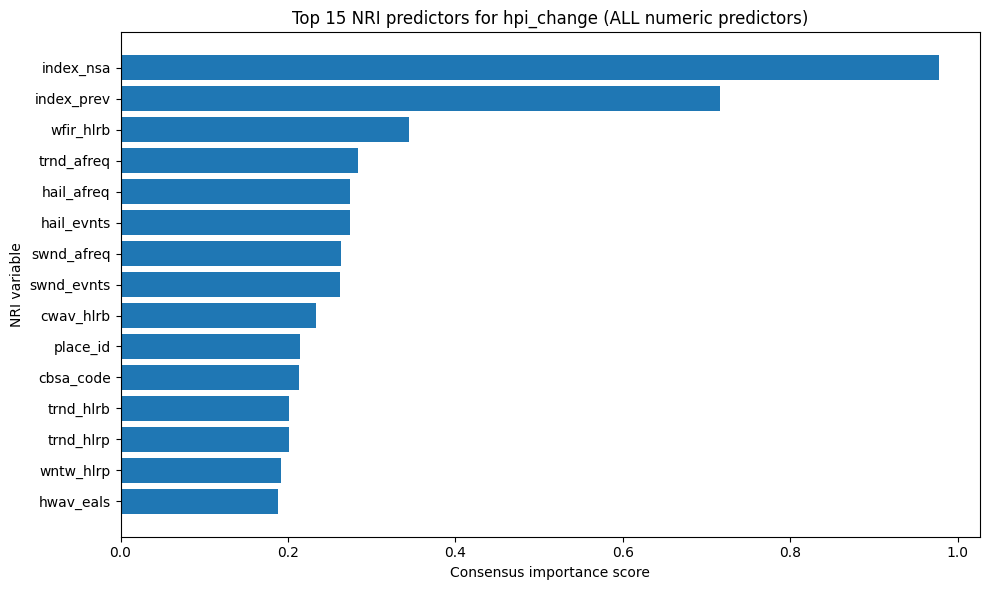

In [ ]:
# ----------------------------
# 9) Save results + plot Top-15
# ----------------------------
top15 = ranked_with_desc.nlargest(15, "consensus_score").sort_values(
    "consensus_score", ascending=False
)[["variable", "consensus_score"]]

plt.figure(figsize=(10, 6))
plt.barh(top15["variable"], top15["consensus_score"])
plt.gca().invert_yaxis()  # highest score at the top
plt.xlabel("Consensus importance score")
plt.ylabel("NRI variable")
plt.title("Top 15 NRI predictors for hpi_change (ALL numeric predictors)")
plt.tight_layout()